# Figure S15: Image Quality Metric Covariance

This notebook plots a clustered Pearson-correlation heatmap across image quality metrics (IQMs) to show how the IQMs co-vary across sessions.


In [27]:
suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(stringr)
  library(ggplot2)
  library(fs)
  library(jsonlite)
  library(scales)
  library(grid)
  library(arrow)
})

find_config_path <- function() {
  env_path <- Sys.getenv("CONFIG_PATH", unset = "")
  if (nzchar(env_path) && file.exists(env_path)) {
    return(normalizePath(env_path, winslash = "/", mustWork = TRUE))
  }

  d <- normalizePath(getwd(), winslash = "/", mustWork = TRUE)
  repeat {
    cand <- file.path(d, "config.json")
    if (file.exists(cand)) {
      return(normalizePath(cand, winslash = "/", mustWork = TRUE))
    }
    parent <- dirname(d)
    if (identical(parent, d)) break
    d <- parent
  }

  stop("Could not locate config.json. Set CONFIG_PATH or launch Jupyter from within the project tree.")
}

config_path <- find_config_path()
config <- jsonlite::fromJSON(config_path)
project_root <- normalizePath(config$project_root, winslash = "/", mustWork = FALSE)

plot_style_file <- fs::path(project_root, "scripts", "utils", "plot_style.R")
if (!file.exists(plot_style_file)) stop("Missing plot style helper: ", plot_style_file)
source(plot_style_file)

plot_style <- get_plot_style(config)
font_family_use <- get_export_font_family()

figure_s15_dir <- fs::path(project_root, "figures", "Supplement", "FigureS15")
fs::dir_create(figure_s15_dir, recurse = TRUE)

harm_path <- fs::path(project_root, "data", "harmonized_data", "merged_data_meisler_analyses_harmonized.parquet")
if (!file.exists(harm_path)) stop("Missing harmonized data parquet: ", harm_path)

iqm_metrics <- c(
  "raw_neighbor_corr", "raw_masked_neighbor_corr",
  "raw_dwi_contrast", "raw_num_bad_slices",
  "raw_coherence_index", "raw_incoherence_index",
  "t1_neighbor_corr", "t1_masked_neighbor_corr",
  "t1_dwi_contrast", "t1_num_bad_slices",
  "t1_coherence_index", "t1_incoherence_index",
  "t1post_neighbor_corr", "t1post_masked_neighbor_corr",
  "t1post_dwi_contrast", "t1post_num_bad_slices",
  "t1post_coherence_index", "t1post_incoherence_index",
  "mean_fd", "max_fd", "max_rotation", "max_translation",
  "max_rel_rotation", "max_rel_translation", "t1_dice_distance",
  "CNR0_mean", "CNR1_mean", "CNR2_mean", "CNR3_mean", "CNR4_mean",
  "CNR0_median", "CNR1_median", "CNR2_median", "CNR3_median", "CNR4_median",
  "CNR0_standard_deviation", "CNR1_standard_deviation", "CNR2_standard_deviation",
  "CNR3_standard_deviation", "CNR4_standard_deviation", "qc_prediction"
)
motion_iqms <- c(
  "mean_fd", "max_fd", "max_rotation", "max_translation",
  "max_rel_rotation", "max_rel_translation"
)

cnr_shell_label <- function(shell_id) {
  switch(
    shell_id,
    "0" = "tSNR (b=0)",
    "1" = "CNR (b=500)",
    "2" = "CNR (b=1000)",
    "3" = "CNR (b=2000)",
    "4" = "CNR (b=3000)",
    "CNR"
  )
}

cnr_shell_value <- c(
  "0" = 0,
  "1" = 500,
  "2" = 1000,
  "3" = 2000,
  "4" = 3000
)

format_iqm_label <- function(iqm) {
  if (iqm == "qc_prediction") return("Quality Classifier Score")
  if (iqm == "t1_dice_distance") return("dMRI-T1w Dice Distance")
  if (iqm %in% motion_iqms) {
    name_map <- c(
      "mean_fd" = "Mean Framewise Displacement",
      "max_fd" = "Max Framewise Displacement",
      "max_rotation" = "Max Rotation",
      "max_translation" = "Max Translation",
      "max_rel_rotation" = "Max Relative Rotation (Derivative)",
      "max_rel_translation" = "Max Relative Translation (Derivative)"
    )
    return(unname(name_map[[iqm]]))
  }
  if (str_detect(iqm, "^CNR[0-4]_(mean|median|standard_deviation)$")) {
    shell_id <- str_match(iqm, "^CNR([0-4])_")[, 2]
    stat <- str_match(iqm, "^(?:CNR[0-4]_)(mean|median|standard_deviation)$")[, 2]
    stat_label <- recode(stat, mean = "Mean", median = "Median", standard_deviation = "SD")
    shell_label <- cnr_shell_label(shell_id)
    shell_label <- sub("\\)$", paste0("; ", stat_label, ")"), shell_label)
    return(shell_label)
  }
  prefix <- case_when(
    str_starts(iqm, "raw_") ~ "Raw",
    str_starts(iqm, "t1post_") ~ "Preprocessed (post-B1)",
    str_starts(iqm, "t1_") ~ "Preprocessed (pre-B1)",
    TRUE ~ ""
  )
  base <- iqm %>%
    str_remove("^raw_") %>%
    str_remove("^t1post_") %>%
    str_remove("^t1_")
  is_masked <- str_starts(base, "masked_")
  core_base <- if (is_masked) str_remove(base, "^masked_") else base
  base_label <- case_when(
    core_base == "neighbor_corr" ~ "Neighboring dMRI Correlation",
    core_base == "dwi_contrast" ~ "dMRI Contrast",
    core_base == "num_bad_slices" ~ "Number of Bad Slices",
    core_base == "coherence_index" ~ "Coherence Index",
    core_base == "incoherence_index" ~ "Incoherence Index",
    TRUE ~ core_base
  )
  qualifier_parts <- character(0)
  if (nzchar(prefix)) {
    q <- prefix %>%
      str_replace("Preprocessed (post-B1)", "Preprocessed, post-B1") %>%
      str_replace("Preprocessed (pre-B1)", "Preprocessed, pre-B1")
    qualifier_parts <- c(qualifier_parts, q)
  }
  if (is_masked) qualifier_parts <- c(qualifier_parts, "Masked")
  if (length(qualifier_parts) > 0) {
    paste0(base_label, " (", paste(qualifier_parts, collapse = ", "), ")")
  } else {
    base_label
  }
}

qualifier_expr <- function(text) {
  switch(
    text,
    "Raw" = bquote(Raw),
    "Masked" = bquote(Masked),
    "Preprocessed (post-B1)" = bquote("Preprocessed, post-" * italic(B) * "1"),
    "Preprocessed (pre-B1)" = bquote("Preprocessed, pre-" * italic(B) * "1"),
    bquote(.(text))
  )
}

format_iqm_label_expr <- function(iqm) {
  if (iqm == "qc_prediction") return(expression("Quality Classifier Score"))
  if (iqm == "t1_dice_distance") return(expression("dMRI-T1w Dice Distance"))
  if (iqm %in% motion_iqms) {
    name_map <- c(
      "mean_fd" = "Mean Framewise Displacement",
      "max_fd" = "Max Framewise Displacement",
      "max_rotation" = "Max Rotation",
      "max_translation" = "Max Translation",
      "max_rel_rotation" = "Max Relative Rotation (Derivative)",
      "max_rel_translation" = "Max Relative Translation (Derivative)"
    )
    return(bquote(.(name_map[[iqm]])))
  }
  if (str_detect(iqm, "^CNR[0-4]_(mean|median|standard_deviation)$")) {
    shell_id <- str_match(iqm, "^CNR([0-4])_")[, 2]
    stat <- str_match(iqm, "^(?:CNR[0-4]_)(mean|median|standard_deviation)$")[, 2]
    stat_label <- recode(stat, mean = "Mean", median = "Median", standard_deviation = "SD")
    shell_label <- if (shell_id == "0") "tSNR" else "CNR"
    shell_value <- cnr_shell_value[[shell_id]]
    return(bquote(.(shell_label) ~ "(" * italic(b) == .(shell_value) * "; " * .(stat_label) * ")"))
  }
  prefix <- case_when(
    str_starts(iqm, "raw_") ~ "Raw",
    str_starts(iqm, "t1post_") ~ "Preprocessed (post-B1)",
    str_starts(iqm, "t1_") ~ "Preprocessed (pre-B1)",
    TRUE ~ ""
  )
  base <- iqm %>%
    str_remove("^raw_") %>%
    str_remove("^t1post_") %>%
    str_remove("^t1_")
  is_masked <- str_starts(base, "masked_")
  core_base <- if (is_masked) str_remove(base, "^masked_") else base
  base_label <- case_when(
    core_base == "neighbor_corr" ~ "Neighboring dMRI Correlation",
    core_base == "dwi_contrast" ~ "dMRI Contrast",
    core_base == "num_bad_slices" ~ "Number of Bad Slices",
    core_base == "coherence_index" ~ "Coherence Index",
    core_base == "incoherence_index" ~ "Incoherence Index",
    TRUE ~ core_base
  )
  qualifiers <- list()
  if (nzchar(prefix)) qualifiers <- c(qualifiers, qualifier_expr(prefix))
  if (is_masked) qualifiers <- c(qualifiers, qualifier_expr("Masked"))
  if (length(qualifiers) > 0) {
    qualifier_combined <- qualifiers[[1]]
    if (length(qualifiers) > 1) {
      for (next_q in qualifiers[-1]) {
        qualifier_combined <- bquote(.(qualifier_combined) * ", " * .(next_q))
      }
    }
    return(bquote(.(base_label) ~ " (" * .(qualifier_combined) * ")"))
  }
  bquote(.(base_label))
}



[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Supplement/FigureS15/S15_harmonized_iqm_correlation_clustered.pdf

[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Supplement/FigureS15/S15_harmonized_iqm_correlation_clustered.png



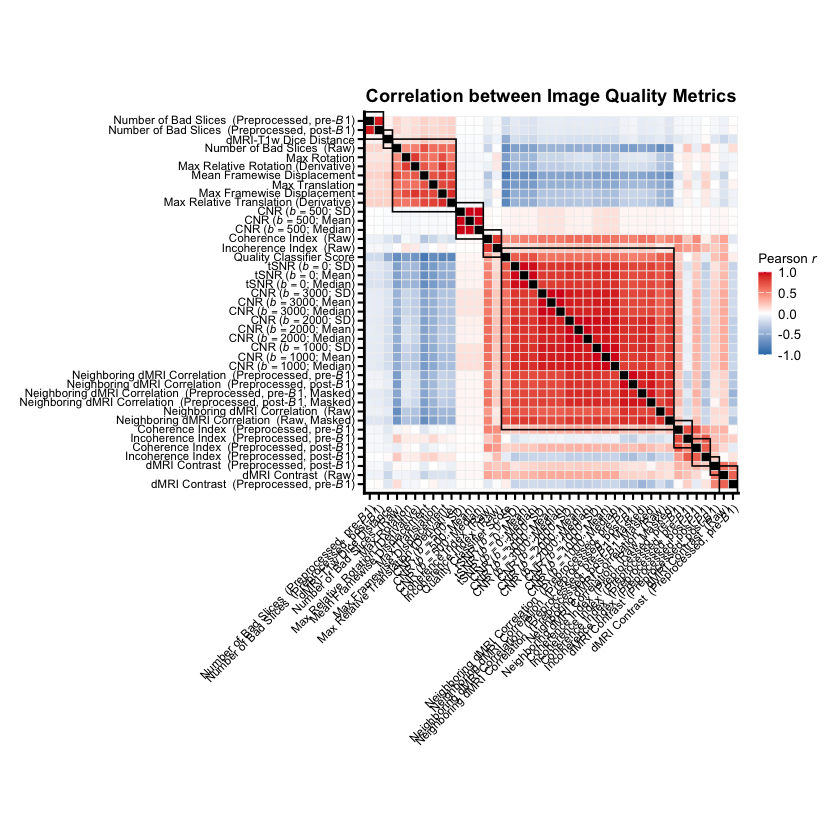

In [ ]:
available_cols <- arrow::open_dataset(harm_path, format = "parquet")$schema$names
needed_cols <- intersect(iqm_metrics, available_cols)
if (length(needed_cols) < 2) {
  stop("Harmonized parquet is missing too many IQM columns: ", paste(setdiff(iqm_metrics, available_cols), collapse = ", "))
}

df_iqm <- arrow::read_parquet(harm_path, col_select = all_of(needed_cols)) %>%
  mutate(across(everything(), as.numeric))

non_missing <- vapply(df_iqm, function(col) sum(!is.na(col)), integer(1))
unique_counts <- vapply(df_iqm, function(col) length(unique(na.omit(col))), integer(1))
keep_cols <- names(df_iqm)[non_missing >= 2 & unique_counts >= 2]
if (length(keep_cols) < 2) {
  stop("Need at least two IQMs with enough usable data to compute correlations.")
}

df_iqm <- df_iqm %>% select(all_of(keep_cols))

bounds <- vapply(df_iqm, function(col) quantile(col, c(0.005, 0.995), na.rm = TRUE), numeric(2))
lower_bounds <- bounds[1, ]
upper_bounds <- bounds[2, ]
mask_list <- Map(function(col, low, high) {
  is.na(col) | (col >= low & col <= high)
}, df_iqm, lower_bounds, upper_bounds)
mask_matrix <- do.call(cbind, mask_list)
keep_rows <- rowSums(mask_matrix) == ncol(df_iqm)
df_iqm <- df_iqm[keep_rows, , drop = FALSE]
if (nrow(df_iqm) == 0) {
  stop("Outlier filtering removed all IQM rows for Figure S15.")
}

mat <- df_iqm %>% as.matrix()
mat <- apply(mat, 2, as.numeric)

current_cols <- colnames(mat)
repeat {
  cor_mat <- cor(mat, method = "pearson", use = "pairwise.complete.obs")
  if (!any(is.na(cor_mat))) break
  na_cols <- rownames(cor_mat)[apply(is.na(cor_mat), 1, any)]
  current_cols <- setdiff(current_cols, na_cols)
  if (length(current_cols) < 2) {
    stop("Correlation matrix still contains NA entries after dropping columns with insufficient overlap.")
  }
  mat <- mat[, current_cols, drop = FALSE]
}
colnames(cor_mat) <- current_cols
rownames(cor_mat) <- current_cols

dist_mat <- as.dist(1 - cor_mat)
hc <- hclust(dist_mat, method = "average")
iqm_order <- colnames(cor_mat)[hc$order]
label_expr_list <- lapply(iqm_order, format_iqm_label_expr)
label_map_expr <- structure(do.call(c, label_expr_list), names = iqm_order)

heat_df <- as.data.frame(as.table(cor_mat), stringsAsFactors = FALSE) %>%
  rename(iqm_y = Var1, iqm_x = Var2, rho = Freq) %>%
  mutate(
    is_diag = iqm_x == iqm_y,
    iqm_x = factor(iqm_x, levels = iqm_order),
    iqm_y = factor(iqm_y, levels = rev(iqm_order))
  )

k_clusters <- min(10, length(iqm_order))
cluster_assign <- cutree(hc, k = k_clusters)

cluster_df <- tibble(
  iqm_metric = names(cluster_assign),
  cluster = unname(cluster_assign),
  x = match(names(cluster_assign), iqm_order)
) %>%
  arrange(x)

cluster_bounds <- cluster_df %>%
  group_by(cluster) %>%
  summarise(
    xmin = min(x) - 0.5,
    xmax = max(x) + 0.5,
    .groups = "drop"
  ) %>%
  mutate(
    ymin = length(iqm_order) - xmax + 0.5,
    ymax = length(iqm_order) - xmin + 1.5
  )

p_s15 <- ggplot() +
  geom_tile(
    data = filter(heat_df, !is_diag),
    aes(x = iqm_x, y = iqm_y, fill = rho),
    color = "#F0F0F0",
    linewidth = 0.2
  ) +
  geom_tile(
    data = filter(heat_df, is_diag),
    aes(x = iqm_x, y = iqm_y),
    fill = "black",
    color = "#F0F0F0",
    linewidth = 0.2
  ) +
  geom_rect(
    data = cluster_bounds,
    aes(xmin = xmin, xmax = xmax, ymin = ymin, ymax = ymax),
    inherit.aes = FALSE,
    fill = NA,
    color = "black",
    linewidth = 0.45
  ) +
  scale_fill_gradient2(
    low = "#2C7BB6",
    mid = "#FFFFFF",
    high = "#D7191C",
    midpoint = 0,
    limits = c(-1, 1),
    breaks = c(-1, -0.5, 0, 0.5, 1),
    oob = squish,
    name = expression("Pearson " * italic(r))
  ) +
  scale_x_discrete(labels = label_map_expr[iqm_order]) +
  scale_y_discrete(labels = rev(label_map_expr[iqm_order])) +
  coord_fixed(clip = "off") +
  labs(
    x = NULL,
    y = NULL,
    title = "Correlation between Image Quality Metrics"
  ) +
  make_theme_pub(
    style = plot_style,
    legend_position = "right",
    axis_title_pt = 8,
    axis_text_pt = 8,
    legend_title_pt = 8,
    legend_text_pt = 8,
    base_size_pt = 8
  ) +
  theme(
    text = element_text(family = font_family_use),
    axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1, size = 7),
    axis.text.y = element_text(size = 7),
    panel.grid = element_blank(),
    plot.title = element_text(size = 11, hjust = 0.5),
    legend.key.height = unit(10, "pt"),
    legend.key.width = unit(8, "pt"),
    plot.margin = margin(t = 10, r = 10, b = 10, l = 10)
  )

p_s15

save_plot_outputs(
  plot_obj = p_s15,
  stub = "S15_harmonized_iqm_correlation_clustered",
  out_dir = figure_s15_dir,
  width_in = 9,
  height_in = 9
)
